In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
df = pd.read_excel("Cleaned_ABS_Tech_Case_2026_Data.xlsx")

## Self-reported reasons for voluntary termination

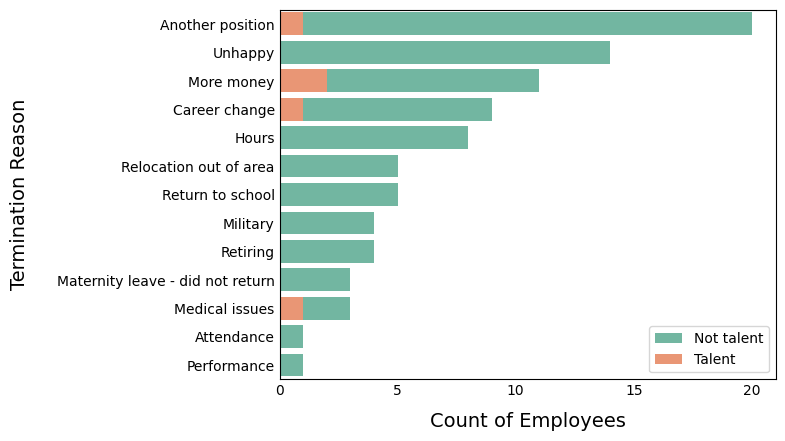

In [2]:
df["TermReason"] = df["TermReason"].astype(str).str.capitalize()

term = df[df["Termd"] == 1]
ct = pd.crosstab(term["TermReason"], [term["EmploymentStatus"], term["is_talent"]])

vol_counts = ct["Voluntarily Terminated"].fillna(0)
vol_counts["Total"] = vol_counts[0] + vol_counts[1]
vol_counts = vol_counts[vol_counts["Total"] > 0].sort_values("Total", ascending=False)

palette = sns.color_palette("Set2", n_colors=2)

sns.barplot(x=vol_counts["Total"], y=vol_counts.index, color=palette[0], label="Not talent")
sns.barplot(x=vol_counts[1], y=vol_counts.index, color=palette[1], label="Talent")

ax = plt.gca()
ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter("{x:.0f}"))

ax.grid(False)
ax.tick_params(axis="y", length=0)
ax.tick_params(axis="x", length=0)

plt.xlabel("Count of Employees", fontsize=14, labelpad=10)
plt.ylabel("Termination Reason", fontsize=14, labelpad=20)

plt.legend()
plt.show()

In [3]:
df.columns

Index(['Employee.Name', 'PerfScore', 'PerformanceScore', 'GenderID', 'Salary',
       'Termd', 'PositionID', 'Position', 'State', 'Zip', 'DOB', 'MaritalDesc',
       'CitizenDesc', 'HispanicLatino', 'RaceDesc', 'DateofHire',
       'DateofTermination', 'TermReason', 'EmploymentStatus', 'Department',
       'RecruitmentSource', 'EngagementSurvey', 'EmpSatisfaction',
       'SpecialProjectsCount', 'DaysLateLast30', 'Absences', 'ManPos',
       'TechLev', 'JobStr', 'ProjColl', 'ProjSelf', 'ProjLead', 'TeamIden',
       'OrgIden', 'CarOpp', 'PsySafe', 'Feedback', 'Trust', 'Network',
       'Remote', 'AIUse', 'AIConf', 'TrainHours', 'WLF', 'InnoCont',
       'technical_score', 'personal_score', 'interpersonal_score',
       'talent_score', 'is_talent'],
      dtype='object')

In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# 1. Define the features from your image
features = [
    'CarOpp', 'OrgIden', 'ProjSelf', 'Trust', 'ProjColl', 
    'TeamIden', 'ProjLead', 'AIConf', 'PsySafe', 'Feedback', 
    'Network', 'AIUse', 'SpecialProjectsCount', 'TechLev', 
    'ManPos', 'InnoCont', 'TrainHours'
]

# 2. Prepare Data
X = df[features]
y = df['is_talent']

# Ensure categorical data is encoded (if any of these are strings)
X = pd.get_dummies(X, drop_first=True)

# Handle missing values (Random Forest doesn't like NaNs)
X = X.fillna(X.median())

# 3. Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Train Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 5. Output Feature Importances (the "Coefficients" of Random Forest)
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("--- Feature Importance ---")
print(importance_df)

# 6. Evaluate
y_pred = rf_model.predict(X_test)
print("\n--- Model Performance ---")

print(classification_report(y_test, y_pred))

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Get predictions for the training data
y_train_pred = rf_model.predict(X_train)

# 2. Print Classification Report
print("--- Training Classification Report ---")
# This provides Precision, Recall, and F1-score for each class
print(classification_report(y_train, y_train_pred))

# 3. Print Confusion Matrix
print("--- Training Confusion Matrix ---")
# Format: [ [TN, FP], [FN, TP] ]
print(confusion_matrix(y_train, y_train_pred))

# 4. Print Overall Accuracy
train_acc = accuracy_score(y_train, y_train_pred)
print(f"\nOverall Training Accuracy: {train_acc:.4f}")

print("\n--- Class Proportions ---")
print(f"Original: {y.value_counts(normalize=True).to_dict()}")
print(f"Train:    {y_train.value_counts(normalize=True).to_dict()}")
print(f"Test:     {y_test.value_counts(normalize=True).to_dict()}")

--- Feature Importance ---
                 Feature  Importance
16            TrainHours    0.194624
15              InnoCont    0.133488
13               TechLev    0.127067
7                 AIConf    0.122574
12  SpecialProjectsCount    0.116388
11                 AIUse    0.112393
6               ProjLead    0.021757
0                 CarOpp    0.020792
9               Feedback    0.019039
4               ProjColl    0.018940
10               Network    0.018521
2               ProjSelf    0.018504
3                  Trust    0.017725
8                PsySafe    0.016520
1                OrgIden    0.014871
5               TeamIden    0.014295
14                ManPos    0.012500

--- Model Performance ---
              precision    recall  f1-score   support

           0       0.94      0.94      0.94        50
           1       0.77      0.77      0.77        13

    accuracy                           0.90        63
   macro avg       0.85      0.85      0.85        63
weighted

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# 1. Define the features
features = [
    'CarOpp', 'OrgIden', 'ProjSelf', 'Trust', 'ProjColl', 
    'TeamIden', 'ProjLead', 'AIConf', 'PsySafe', 'Feedback', 
    'Network', 'AIUse', 'SpecialProjectsCount', 'TechLev', 
    'ManPos', 'InnoCont', 'TrainHours'
]

# 2. Prepare Data
X = df[features]
y = df['is_talent']

# Preprocessing
X = pd.get_dummies(X, drop_first=True)
X = X.fillna(X.median())

# 3. Stratified Split
# Adding 'stratify=y' ensures the class proportions are preserved
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  # <--- This is the key change
)

# 4. Train Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 5. Output Feature Importances
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("--- Feature Importance ---")
print(importance_df)

# 6. Evaluate
y_pred = rf_model.predict(X_test)
print("\n--- Model Performance ---")
print(classification_report(y_test, y_pred))

# Verification: Check proportions
print("\n--- Class Proportions ---")
print(f"Original: {y.value_counts(normalize=True).to_dict()}")
print(f"Train:    {y_train.value_counts(normalize=True).to_dict()}")
print(f"Test:     {y_test.value_counts(normalize=True).to_dict()}")

--- Feature Importance ---
                 Feature  Importance
16            TrainHours    0.205305
15              InnoCont    0.166587
7                 AIConf    0.129765
11                 AIUse    0.123369
13               TechLev    0.100436
12  SpecialProjectsCount    0.060727
2               ProjSelf    0.027457
0                 CarOpp    0.024777
6               ProjLead    0.021961
14                ManPos    0.020277
1                OrgIden    0.020038
9               Feedback    0.019865
4               ProjColl    0.019357
10               Network    0.015997
3                  Trust    0.015560
5               TeamIden    0.014863
8                PsySafe    0.013658

--- Model Performance ---
              precision    recall  f1-score   support

           0       0.91      0.98      0.94        50
           1       0.89      0.62      0.73        13

    accuracy                           0.90        63
   macro avg       0.90      0.80      0.83        63
weighted